In [ ]:
!wget https://www.dropbox.com/s/nilt43hyl1dx82k/dataset.zip?dl=0

--2022-08-02 18:20:43--  https://www.dropbox.com/s/nilt43hyl1dx82k/dataset.zip?dl=0
Resolving www.dropbox.com (www.dropbox.com)... 162.125.5.18, 2620:100:601d:18::a27d:512
Connecting to www.dropbox.com (www.dropbox.com)|162.125.5.18|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: /s/raw/nilt43hyl1dx82k/dataset.zip [following]
--2022-08-02 18:20:43--  https://www.dropbox.com/s/raw/nilt43hyl1dx82k/dataset.zip
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uce03c8a9665d10f4d0a281ca471.dl.dropboxusercontent.com/cd/0/inline/BqQosHE2UFLjlaEAYTMeRuGOfeFXAsXIEx7k0PcqTeibuqzZcOYluBezRtZzAYtE7DpHWImW_OhcClPud6tqARvsSZZjzcTgr3i-rykjv-ATcG_HgqF2GtkEK-jc7Mpt67i4FTgXhJ4x2KhggZxHAmC1Up8jv2B-rwqX0dtFB3ZbJw/file# [following]
--2022-08-02 18:20:43--  https://uce03c8a9665d10f4d0a281ca471.dl.dropboxusercontent.com/cd/0/inline/BqQosHE2UFLjlaEAYTMeRuGOfeFXAsXIEx7k0PcqTeibuqzZcOYluBezRtZzAYtE7D

In [ ]:
!unzip dataset.zip?dl=0

Streaming output truncated to the last 5000 lines.
  inflating: train/sad/Training_65242339.jpg  
  inflating: train/sad/Training_65267116.jpg  
  inflating: train/sad/Training_65275626.jpg  
  inflating: train/sad/Training_6529266.jpg  
  inflating: train/sad/Training_65329617.jpg  
  inflating: train/sad/Training_65338712.jpg  
  inflating: train/sad/Training_65338797.jpg  
  inflating: train/sad/Training_65387162.jpg  
  inflating: train/sad/Training_65404494.jpg  
  inflating: train/sad/Training_65426218.jpg  
  inflating: train/sad/Training_65430136.jpg  
  inflating: train/sad/Training_65437377.jpg  
  inflating: train/sad/Training_6545735.jpg  
  inflating: train/sad/Training_65463385.jpg  
  inflating: train/sad/Training_65473985.jpg  
  inflating: train/sad/Training_65502829.jpg  
  inflating: train/sad/Training_65505359.jpg  
  inflating: train/sad/Training_65508578.jpg  
  inflating: train/sad/Training_65516023.jpg  
  inflating: train/sad/Training_65524027.jpg  
  inflating

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from keras.layers import Flatten, Dense
from keras.models import Model
from keras.preprocessing.image import ImageDataGenerator , img_to_array, load_img
from keras.applications.mobilenet import MobileNet, preprocess_input 
from keras.losses import categorical_crossentropy

In [ ]:
# Working with pre trained model 

base_model = MobileNet( input_shape=(224,224,3), include_top= False )

for layer in base_model.layers:
  layer.trainable = False


x = Flatten()(base_model.output)
x = Dense(units=7 , activation='softmax' )(x)

# creating our model.
model = Model(base_model.input, x)

17235968/17225924 [==============================] - 0s 0us/step


In [ ]:
model.compile(optimizer='adam', loss= categorical_crossentropy , metrics=['accuracy']  )

In [ ]:
train_datagen = ImageDataGenerator(
     zoom_range = 0.2, 
     shear_range = 0.2, 
     horizontal_flip=True, 
     rescale = 1./255)

train_data = train_datagen.flow_from_directory(directory= "/content/train", 
                                               target_size=(224,224), 
                                               batch_size=32,)


train_data.class_indices

Found 28709 images belonging to 7 classes.


{'angry': 0,
 'disgust': 1,
 'fear': 2,
 'happy': 3,
 'neutral': 4,
 'sad': 5,
 'surprise': 6}

In [ ]:


val_datagen = ImageDataGenerator(rescale = 1./255 )

val_data = val_datagen.flow_from_directory(directory= "/content/test", 
                                           target_size=(224,224), 
                                           batch_size=32,)



Found 7178 images belonging to 7 classes.


In [ ]:
## having early stopping and model check point 

from keras.callbacks import ModelCheckpoint, EarlyStopping

# early stopping
es = EarlyStopping(monitor='val_accuracy', min_delta= 0.01 , patience= 5, verbose= 1, mode='auto')

# model check point
mc = ModelCheckpoint(filepath="best_model.h5", monitor= 'val_accuracy', verbose= 1, save_best_only= True, mode = 'auto')

# puting call back in a list 
call_back = [es, mc]

In [ ]:
hist = model.fit(train_data, 
                           steps_per_epoch= 10, 
                           epochs= 30, 
                           validation_data= val_data, 
                           validation_steps= 8, 
                           callbacks=[es,mc])

Epoch 1/30
10/10 [==============================] - ETA: 0s - loss: 26.6229 - accuracy: 0.1406
Epoch 1: val_accuracy improved from -inf to 0.22656, saving model to best_model.h5
10/10 [==============================] - 24s 2s/step - loss: 26.6229 - accuracy: 0.1406 - val_loss: 12.1597 - val_accuracy: 0.2266
Epoch 2/30
10/10 [==============================] - ETA: 0s - loss: 12.8754 - accuracy: 0.3094
Epoch 2: val_accuracy improved from 0.22656 to 0.36328, saving model to best_model.h5
10/10 [==============================] - 26s 3s/step - loss: 12.8754 - accuracy: 0.3094 - val_loss: 10.2517 - val_accuracy: 0.3633
Epoch 3/30
10/10 [==============================] - ETA: 0s - loss: 6.6101 - accuracy: 0.3625
Epoch 3: val_accuracy improved from 0.36328 to 0.42578, saving model to best_model.h5
10/10 [==============================] - 22s 2s/step - loss: 6.6101 - accuracy: 0.3625 - val_loss: 6.1857 - val_accuracy: 0.4258
Epoch 4/30
10/10 [==============================] - ETA: 0s - loss: 6.

In [ ]:
# Loading the best fit model 
from keras.models import load_model
model = load_model("/content/best_model.h5")

In [ ]:
h =  hist.history
h.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

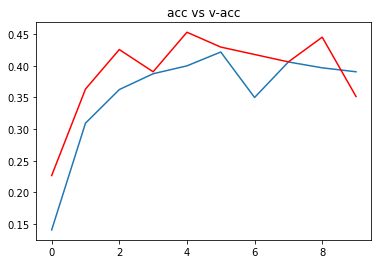

In [ ]:
plt.plot(h['accuracy'])
plt.plot(h['val_accuracy'] , c = "red")
plt.title("acc vs v-acc")
plt.show()

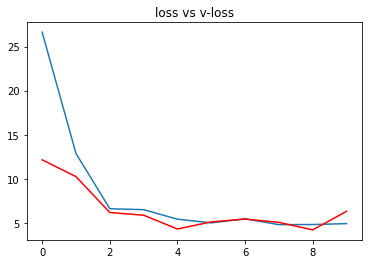

In [ ]:
plt.plot(h['loss'])
plt.plot(h['val_loss'] , c = "red")
plt.title("loss vs v-loss")
plt.show()

In [ ]:
# just to map o/p values 
op = dict(zip( train_data.class_indices.values(), train_data.class_indices.keys()))

In [ ]:
!wget 'https://i.imgflip.com/1hozrp.jpg'

--2022-08-02 18:31:00--  https://i.imgflip.com/1hozrp.jpg
Resolving i.imgflip.com (i.imgflip.com)... 104.18.64.15, 104.18.255.14
Connecting to i.imgflip.com (i.imgflip.com)|104.18.64.15|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 30047 (29K) [image/jpeg]
Saving to: ‘1hozrp.jpg’

1hozrp.jpg          100%[===================>]  29.34K  --.-KB/s    in 0s      

2022-08-02 18:31:00 (96.6 MB/s) - ‘1hozrp.jpg’ saved [30047/30047]



 the image is of happy


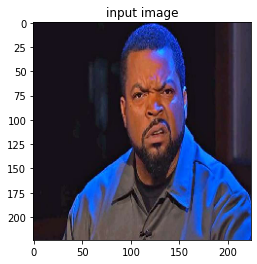

In [ ]:
# path for the image to see if it predics correct class

path = '/content/1hozrp.jpg'
img = load_img(path, target_size=(224,224) )

i = img_to_array(img)/255
input_arr = np.array([i])
input_arr.shape

pred = np.argmax(model.predict(input_arr))

print(f" the image is of {op[pred]}")

# to display the image  
plt.imshow(input_arr[0])
plt.title("input image")
plt.show()